What type of machine learning problem is this?
regression
supervised
target variable is the house price

What evaluation metrics do you expect will matter for this problem?
MAE - it will give the absolute error 
RMSE - it will give the square error and convert it to units of the target variable. It penalizes large errors well, so presence of large errors can be detected
R2 - it will give the overall variance detected by the model or how well the model is compared to just predicting the mean


Based on the column names alone:

What types of features do you expect?
MSSubClass - Categorical
MSZoning - Categorical
LotFrontage - Numerical
LotArea - Numerical
Street - Categorical 	
Alley - Categorical	
LotShape - Categorical
LandContour - Categorical
Utilities - Categorical
LotConfig - Categorical
LandSlope - Categorical
Neighborhood - Categorical
Condition1 - Categorical
Condition2 - Categorical
BldgType - Categorical
HouseStyle - Categorical
OverallQual - Ordinal 
OverallCond - Ordinal
YearBuilt - Numerical
YearRemodAdd - Numerical 
RoofStyle - Categorical
RoofMatl - Categorical
Exterior1st - Categorical
Exterior2nd - Categorical
MasVnrType - Categorical
MasVnrArea - Numerical
ExterQual - Ordinal
ExterCond - Ordinal
Foundation - Categorical
BsmtQual - Ordinal
BsmtCond - Ordinal


What factors should logically influence house price?
Size of house
Age of the house
Location Area
Facilities nearby
Condition of the house
Natural resources availability
Space surrounding the house
Quality of the building materials

In [15]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('../data/train.csv')

In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

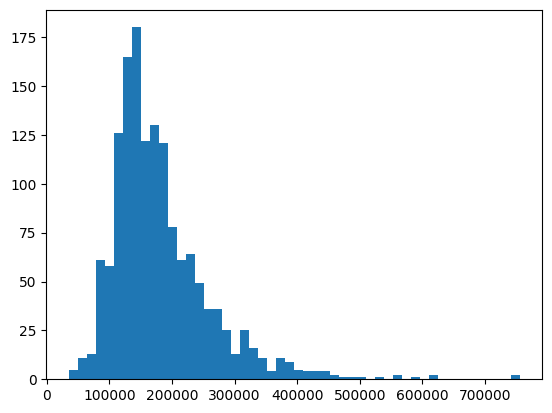

In [13]:
import matplotlib.pyplot as plt

plt.hist(df['SalePrice'], bins=50)
plt.show()

In [18]:
y = np.log(df["SalePrice"])
X = df.drop("SalePrice", axis=1)

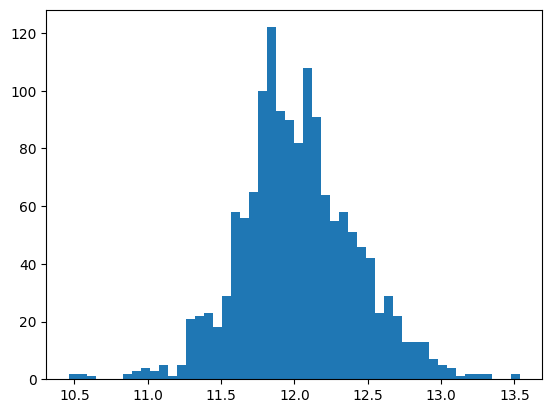

In [17]:
plt.hist(y, bins=50)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)

(1168, 80)
(292, 80)


In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

In [ ]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

PoolQC                                                       1453
MiscFeature                                                  1406
Alley                                                        1369
Fence                                                        1179
MasVnrType                                                    872
FireplaceQu                                                   690
LotFrontage                                                   259
GarageQual                                                     81
GarageFinish                                                   81
GarageType                                                     81
GarageYrBlt                                                    81
GarageCond                                                     81
BsmtFinType2                                                   38
BsmtExposure                                                   38
BsmtCond                                                       37
BsmtQual  

In [31]:
missing_perc = (missing_counts / len(df))*100
print(missing_perc)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


PoolQC - feature does not exist\
Fence - feature does not exist\
FireplaceQu - feature does not exist\
Alley - feature does not exist\
MiscFeature - feature does not exist